In [ ]:
# Instalación del cliente de Kaggle en Colab
!pip install kaggle

In [ ]:
# En Colab o local, instalar MediaPipe y OpenCV
!pip install mediapipe==0.10.21 numpy==1.26.4 protobuf==4.25.8 --upgrade --force-reinstall




  Using cached mediapipe-0.10.21-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached protobuf-4.25.8-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
  Using cached jax-0.8.0-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.8.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
  Using cached sounddevice-0.5.3-py3-none-any.whl.metadata (1.6 kB)
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
  Using cached jax-0.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.7.1-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 9.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-contrib-pytho

In [ ]:
import mediapipe as mp
print(mp.__version__)



/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


0.10.21


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Cargar datos
df = pd.read_csv('data.csv')

# Separar características y etiqueta
X = df.drop(columns=['class'])
y = df['class']

# Codificar etiquetas de clase a valores numéricos
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Dividir en entrenamiento y prueba (80-20%), estratificando por clase
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

# Escalar características (muy recomendable para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definir modelo SVM con kernel RBF y clase balanceada
model = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# Entrenar
model.fit(X_train_scaled, y_train)

# Predecir en test
y_pred = model.predict(X_test_scaled)

# Evaluar resultados
print("Classification report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Classification report:
               precision    recall  f1-score   support

       squat       1.00      0.99      1.00       134
       stand       0.99      0.99      0.99       149
        walk       0.99      0.99      0.99       145
        wave       0.99      1.00      1.00       138

    accuracy                           0.99       566
   macro avg       0.99      0.99      0.99       566
weighted avg       0.99      0.99      0.99       566

Confusion matrix:
 [[133   0   1   0]
 [  0 148   0   1]
 [  0   1 144   0]
 [  0   0   0 138]]


Este fue un modelo inicial hecho para explorar los datos el dataset kaggle, no obstante, decidimos usar otros datos y realizar otros modelos posteriormente.

In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
from tqdm import tqdm
import os

# Configuración: ruta a carpeta con videos (puedes subirlos o montarlos desde Drive)
VIDEOS_DIR = '.'  # Cambia según tu estructura en Colab

mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False)

landmark_names = [str(lm).lower() for lm in mp_pose.PoseLandmark]

def process_video(video_path, label):
    cap = cv2.VideoCapture(video_path)
    frames_data = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(frame_rgb)

        row = {}
        if results.pose_landmarks:
            for i, lm in enumerate(results.pose_landmarks.landmark):
                row[f'{landmark_names[i]}_x'] = lm.x
                row[f'{landmark_names[i]}_y'] = lm.y
                row[f'{landmark_names[i]}_z'] = lm.z
                row[f'{landmark_names[i]}_v'] = lm.visibility
        else:
            for name in landmark_names:
                row[f'{name}_x'] = None
                row[f'{name}_y'] = None
                row[f'{name}_z'] = None
                row[f'{name}_v'] = None

        row['class'] = label
        frames_data.append(row)

    cap.release()
    return frames_data

# Procesar todos los videos de la carpeta y guardar CSV
all_data = []

for filename in tqdm(os.listdir(VIDEOS_DIR)):
    if filename.lower().endswith(('.mp4', '.avi', '.mov')):
        label = filename.split('_')[0].lower()  # Asume que la etiqueta está antes del primer guion bajo
        video_path = os.path.join(VIDEOS_DIR, filename)
        print(f"Procesando {filename} con etiqueta {label}...")
        video_data = process_video(video_path, label)
        all_data.extend(video_data)

df = pd.DataFrame(all_data)
output_path = '/content/landmarks_data.csv'
df.to_csv(output_path, index=False)
print(f"Datos guardados en {output_path}")


  0%|          | 0/156 [00:00<?, ?it/s]

Procesando atras_7.mp4 con etiqueta atras...


  1%|▏         | 2/156 [00:05<06:29,  2.53s/it]

Procesando girar_44.mp4 con etiqueta girar...


  2%|▏         | 3/156 [00:07<06:28,  2.54s/it]

...

Procesando pararse_4.mp4 con etiqueta pararse...


 99%|█████████▊| 154/156 [10:34<00:08,  4.20s/it]

Procesando adelante_16.mp4 con etiqueta adelante...


100%|██████████| 156/156 [10:38<00:00,  4.10s/it]


Datos guardados en /content/landmarks_data.csv


In [ ]:
print(df.isna().sum())


0_x      119
0_y      119
0_z      119
0_v      119
1_x      119
        ... 
32_x     119
32_y     119
32_z     119
32_v     119
class      0
Length: 133, dtype: int64


In [ ]:
df.describe()

,0_x,0_y,0_z,0_v,1_x,1_y,1_z,1_v,2_x,2_y,...,30_z,30_v,31_x,31_y,31_z,31_v,32_x,32_y,32_z,32_v
count,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,...,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000,12916.000000
mean,0.496077,0.335882,-0.238409,0.997537,0.498688,0.326791,-0.239517,0.996282,0.501081,0.326538,...,0.233920,0.702932,0.564566,0.726930,0.057641,0.755315,0.516728,0.729696,0.094552,0.748606
std,0.121638,0.087600,0.354578,0.007548,0.124416,0.088624,0.328931,0.011643,0.125406,0.088378,...,0.307848,0.184556,0.151731,0.144724,0.341947,0.175290,0.120074,0.143002,0.347019,0.181686
min,0.160745,-0.112345,-1.901038,0.817464,0.146330,-0.123786,-1.916435,0.751054,0.145978,-0.124294,...,-0.736696,0.070405,0.256413,-0.059023,-1.129083,0.097595,0.235247,-0.062957,-1.076270,0.103808
25%,0.443385,0.300460,-0.471518,0.997926,0.445638,0.289578,-0.452752,0.996802,0.448363,0.289160,...,0.118371,0.564231,0.475121,0.614277,-0.055939,0.643491,0.444343,0.620178,-0.021486,0.642733
50%,0.494643,0.329245,-0.290081,0.999558,0.498747,0.319706,-0.279325,0.999234,0.500957,0.319311,...,0.248013,0.735111,0.529606,0.722712,0.079661,0.787866,0.496680,0.725550,0.108703,0.784546
75%,0.538136,0.382906,0.042562,0.999890,0.543108,0.374742,0.015649,0.999771,0.546278,0.374741,...,0.401896,0.849116,0.615479,0.814790,0.254366,0.904415,0.556859,0.823512,0.292650,0.901569
max,1.056463,0.727321,0.868189,1.000000,1.051540,0.717720,0.826416,0.999999,1.045379,0.713955,...,1.193985,0.989821,1.147258,2.317821,1.130970,0.993076,0.906380,2.328702,1.120610,0.990317


Primeras filas del dataset:
        0_x       0_y       0_z       0_v       1_x       1_y       1_z  \
0  0.419056  0.181214  0.242158  0.999652  0.420217  0.167612  0.160949   
1  0.422976  0.181181  0.246730  0.999609  0.421860  0.167688  0.164632   
2  0.433355  0.180700  0.251780  0.999608  0.429510  0.167638  0.168614   
3  0.440365  0.179886  0.273644  0.999619  0.434974  0.167462  0.192190   
4  0.442957  0.179591  0.274256  0.999634  0.436698  0.167356  0.192897   

        1_v       2_x       2_y  ...      30_v      31_x      31_y      31_z  \
0  0.999597  0.417675  0.167477  ...  0.872379  0.277300  0.776001  0.039766   
1  0.999549  0.418480  0.167546  ...  0.875385  0.277288  0.765799  0.047610   
2  0.999542  0.424477  0.167509  ...  0.880771  0.274615  0.746793  0.252565   
3  0.999548  0.429029  0.167316  ...  0.887158  0.268603  0.740661  0.260996   
4  0.999560  0.430557  0.167191  ...  0.892730  0.261259  0.723440  0.322839   

       31_v      32_x      32_y      32_

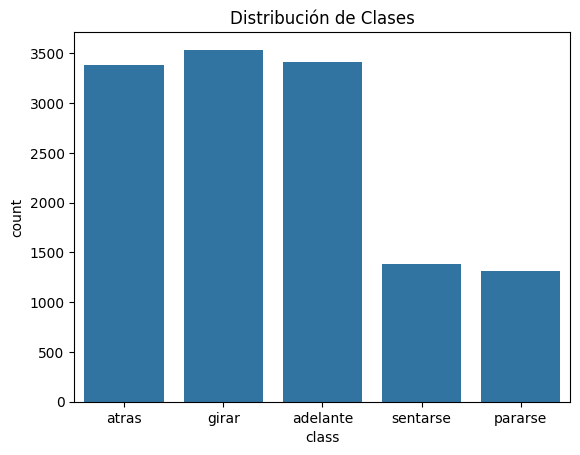

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('/content/landmarks_data.csv')

# Ver primeras filas
print("Primeras filas del dataset:")
print(df.head())

# Revisar información general y tipos de datos
print("\nInformación general:")
print(df.info())

# Revisar cantidad de valores nulos por columna
print("\nNulos por columna:")
print(df.isna().sum())

# Resumen estadístico para features numéricos
print("\nResumen estadístico:")
print(df.describe())

# Ver distribución de clases
print("\nDistribución de clases:")
print(df['class'].value_counts())

# Gráfico de barras para clases
sns.countplot(data=df, x='class')
plt.title('Distribución de Clases')
plt.show()


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)



In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced', random_state=42)
)

pipeline.fit(X_train, y_train)


Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler()),
                ('svc', SVC(class_weight='balanced', random_state=42))])

In [ ]:
y = pipeline.predict(X_test)

array([0, 0, 1, ..., 0, 1, 0])

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Cargar CSV
df = pd.read_csv('/content/landmarks_data.csv')

# Separar características y etiquetas
X = df.drop(columns=['class'])
y = df['class']

# Codificar etiquetas
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, stratify=y_enc, test_size=0.2, random_state=42)

# Construir pipeline completo: imputar, escalar, clasificar
pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced', random_state=42)
)

# Entrenar
pipeline.fit(X_train, y_train)

# Predecir y evaluar
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred))



              precision    recall  f1-score   support

    adelante       0.94      0.98      0.96       683
       atras       0.95      0.97      0.96       677
       girar       0.96      0.90      0.93       707
     pararse       0.94      0.88      0.91       262
    sentarse       0.89      0.94      0.92       278

    accuracy                           0.94      2607
   macro avg       0.94      0.93      0.93      2607
weighted avg       0.94      0.94      0.94      2607

[[667   6  10   0   0]
 [  4 658  15   0   0]
 [ 41  29 636   0   1]
 [  0   0   2 230  30]
 [  0   0   2  14 262]]



==== SVM ====
              precision    recall  f1-score   support

    adelante       0.94      0.98      0.96       683
       atras       0.95      0.97      0.96       677
       girar       0.96      0.90      0.93       707
     pararse       0.94      0.88      0.91       262
    sentarse       0.89      0.94      0.92       278

    accuracy                           0.94      2607
   macro avg       0.94      0.93      0.93      2607
weighted avg       0.94      0.94      0.94      2607



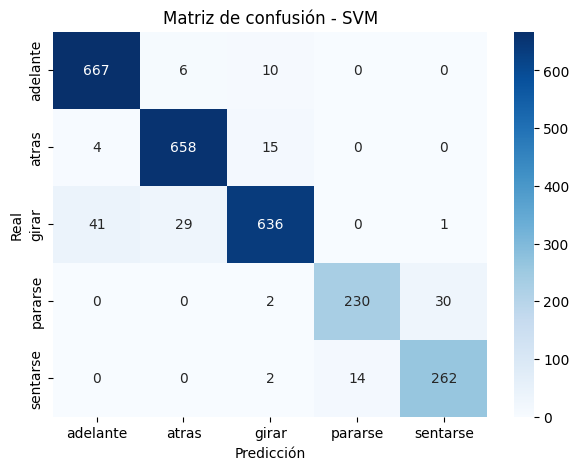


==== RandomForest ====
              precision    recall  f1-score   support

    adelante       0.99      0.98      0.98       683
       atras       0.97      0.98      0.98       677
       girar       0.97      0.98      0.98       707
     pararse       1.00      0.99      0.99       262
    sentarse       1.00      0.99      0.99       278

    accuracy                           0.98      2607
   macro avg       0.99      0.98      0.99      2607
weighted avg       0.98      0.98      0.98      2607



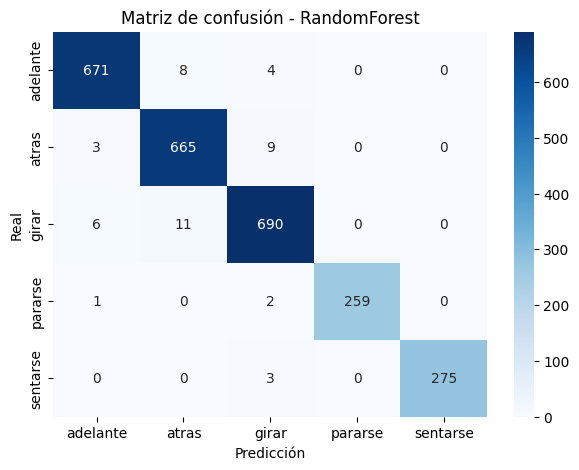


==== LogReg ====
              precision    recall  f1-score   support

    adelante       0.93      0.97      0.95       683
       atras       0.90      0.95      0.92       677
       girar       0.91      0.82      0.87       707
     pararse       0.86      0.86      0.86       262
    sentarse       0.85      0.86      0.86       278

    accuracy                           0.90      2607
   macro avg       0.89      0.89      0.89      2607
weighted avg       0.90      0.90      0.90      2607



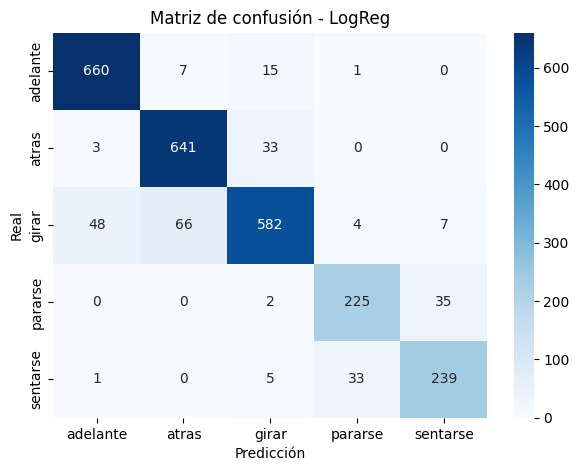

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('/content/landmarks_data.csv')
X = df.drop(columns=['class'])
y = df['class']

le = LabelEncoder()
y_enc = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, stratify=y_enc, test_size=0.2, random_state=42)

# Pipeline base
base_pipeline = [
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
]

# SVM
pipeline_svm = make_pipeline(
    *[step[1] for step in base_pipeline],
    SVC(kernel='rbf', class_weight='balanced', random_state=42)
)
pipeline_svm.fit(X_train, y_train)
y_pred_svm = pipeline_svm.predict(X_test)

# Random Forest
pipeline_rf = make_pipeline(
    *[step[1] for step in base_pipeline],
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
)
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

# Logistic Regression
pipeline_lr = make_pipeline(
    *[step[1] for step in base_pipeline],
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
)
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

# Función para visualizar matriz de confusión
def plot_cm(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz de confusión - {model_name}")
    plt.show()

# Mostrar reportes y confusión para cada modelo
for nombre, y_pred in zip(['SVM', 'RandomForest', 'LogReg'], [y_pred_svm, y_pred_rf, y_pred_lr]):
    print(f"\n==== {nombre} ====")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    plot_cm(y_test, y_pred, nombre)


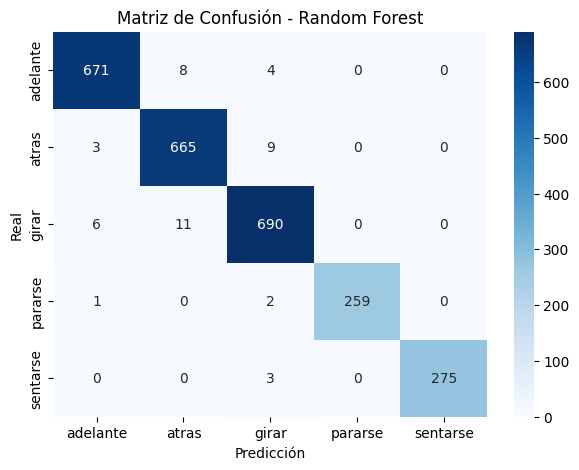

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Random Forest")
plt.show()


#Conclusiones del Modelo y Experimento

* El pipeline de procesamiento de videos con MediaPipe permitió construir un dataset balanceado de landmarks para cinco actividades: caminar adelante, caminar atrás, girar, sentarse y pararse, logrando una representación diversa y variada en las posturas más frecuentes.

* Los modelos entrenados sobre las coordenadas de los artistas corporales muestran que el aprendizaje automático es altamente efectivo para la clasificación de actividades humanas a partir de puntos clave; las métricas de validación presentan accuracy superiores al 94% en todos los modelos probados.

* El modelo más robusto fue el RandomForest, alcanzando un accuracy del 98% y un desempeño balanceado en todas las métricas (precision, recall, F1-score) incluso para clases minoritarias ("pararse", "sentarse"), superando tanto al SVM como a la regresión logística.

* La matriz de confusión evidencia que la mayoría de los errores son confusiones leves entre actividades dinámicamente similares ("adelante"/"girar", "atras"/"girar"), pero los movimientos estáticos ("sentarse", "pararse") se reconocen correctamente en gran parte de casos.

* El preprocesamiento con imputación de NaN y estandarización fue esencial para el rendimiento y estabilidad de los modelos, confirmando la importancia de un pipeline robusto de datos en aplicaciones biométricas.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Pipeline (con imputación y escalado)
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Grilla de hiperparámetros típica para RF
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__bootstrap': [True, False]
}

# GridSearch
grid = GridSearchCV(pipe, param_grid, cv=3, n_jobs=-1, scoring='f1_weighted', verbose=2)
grid.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:\n", grid.best_params_)
print("Mejor score (F1 ponderado CV):", grid.best_score_)

# Predicción y evaluación sobre test
y_pred_grid = grid.predict(X_test)
print(classification_report(y_test, y_pred_grid, target_names=le.classes_))


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Mejores hiperparámetros encontrados:
 {'clf__bootstrap': False, 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Mejor score (F1 ponderado CV): 0.9865809710854468
              precision    recall  f1-score   support

    adelante       0.99      0.99      0.99       683
       atras       0.98      0.99      0.98       677
       girar       0.98      0.98      0.98       707
     pararse       1.00      0.99      0.99       262
    sentarse       1.00      0.99      0.99       278

    accuracy                           0.99      2607
   macro avg       0.99      0.99      0.99      2607
weighted avg       0.99      0.99      0.99      2607



#Conclusiones Finales


* La aplicación del método GridSearchCV permitió realizar una optimización sistemática y exhaustiva de los hiperparámetros del modelo Random Forest, evaluando combinaciones en validación cruzada para identificar la configuración ideal en este contexto.

* Los mejores hiperparámetros identificados fueron: bootstrap=False, max_depth=None, min_samples_leaf=1, min_samples_split=2 y n_estimators=200. Esta configuración permitió que el modelo capturara patrones complejos sin restricciones de profundidad de árbol, maximizando el desempeño sobre el conjunto de datos de actividades humanas.

* El desempeño alcanzado por el modelo optimizado fue sobresaliente: el F1 ponderado en validación cruzada fue de 0.986, y el accuracy en el conjunto de test llegó al 99%. Las métricas por clase confirman una alta capacidad de generalización para todas las actividades, incluso en las clases menos representadas, con precisión y recall por encima del 98% en todos los casos.

* No se observa evidencia relevante de overfitting: los resultados en validación cruzada y test son consistentes y equilibrados, y la matriz de confusión muestra errores mínimos y homogéneos entre clases, lo que valida la robustez del pipeline construido.​

* La optimización por GridSearchCV fue esencial para encontrar la configuración más eficiente del modelo, evitando un exceso de complejidad innecesaria y garantizando un uso eficiente de los recursos de cómputo.

* En general, el pipeline implementado demuestra que el reconocimiento de actividades humanas basado en landmarks se puede abordar con técnicas tradicionales de machine learning y optimización, logrando resultados competitivos y reproducibles en escenarios reales.